In [5]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV


In [12]:
df = pd.read_csv('ml_final_project_data/youtube_shorts_tiktok_trends_2025.csv')
df.head()

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,...,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,...,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,...,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,...,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,...,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,...,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142


In [8]:
# Check dataset structure
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (50000, 32)

Column names:
['trend_label', 'platform', 'region', 'language', 'category', 'traffic_source', 'device_brand', 'creator_tier', 'title_len', 'text_richness', 'like_rate', 'comment_rate', 'share_rate', 'like_rate_log', 'comment_rate_log', 'share_rate_log', 'views_per_day', 'likes_per_day', 'rel_like', 'rel_share', 'rel_combo', 'like_hashtag_interaction', 'share_hashtag_interaction', 'platform_cat', 'region_cat', 'language_cat', 'category_cat', 'traffic_source_cat', 'device_brand_cat', 'creator_tier_cat', 'richness_traffic_interaction', 'weekend_hashtag_boost']

Data types:
trend_label                      object
platform                         object
region                           object
language                         object
category                         object
traffic_source                   object
device_brand                     object
creator_tier                     object
title_len                         int64
text_richness                   flo

In [9]:
# Identify target and features
print("Target variable (trend_label) distribution:")
print(df['trend_label'].value_counts())
print("\nTarget value counts:")
print(df['trend_label'].value_counts(normalize=True))

# Separate features and target
# Assuming 'trend_label' is the target (viral vs non-viral)
target_col = 'trend_label'
y = df[target_col]

# Select only numeric features for correlation analysis
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric features ({len(numeric_features)}):")
print(numeric_features)

Target variable (trend_label) distribution:
trend_label
stable       27696
rising       12500
declining     5098
seasonal      4706
Name: count, dtype: int64

Target value counts:
trend_label
stable       0.55392
rising       0.25000
declining    0.10196
seasonal     0.09412
Name: proportion, dtype: float64

Numeric features (24):
['title_len', 'text_richness', 'like_rate', 'comment_rate', 'share_rate', 'like_rate_log', 'comment_rate_log', 'share_rate_log', 'views_per_day', 'likes_per_day', 'rel_like', 'rel_share', 'rel_combo', 'like_hashtag_interaction', 'share_hashtag_interaction', 'platform_cat', 'region_cat', 'language_cat', 'category_cat', 'traffic_source_cat', 'device_brand_cat', 'creator_tier_cat', 'richness_traffic_interaction', 'weekend_hashtag_boost']


METHOD 1: Quick Random Forest Feature Importance

Top 10 Features by Random Forest Importance:
                  feature  importance
                rel_combo    0.225945
    weekend_hashtag_boost    0.213755
            likes_per_day    0.121169
           share_rate_log    0.058534
            views_per_day    0.055171
               share_rate    0.051898
share_hashtag_interaction    0.051278
                rel_share    0.042015
                like_rate    0.036868
            like_rate_log    0.036216


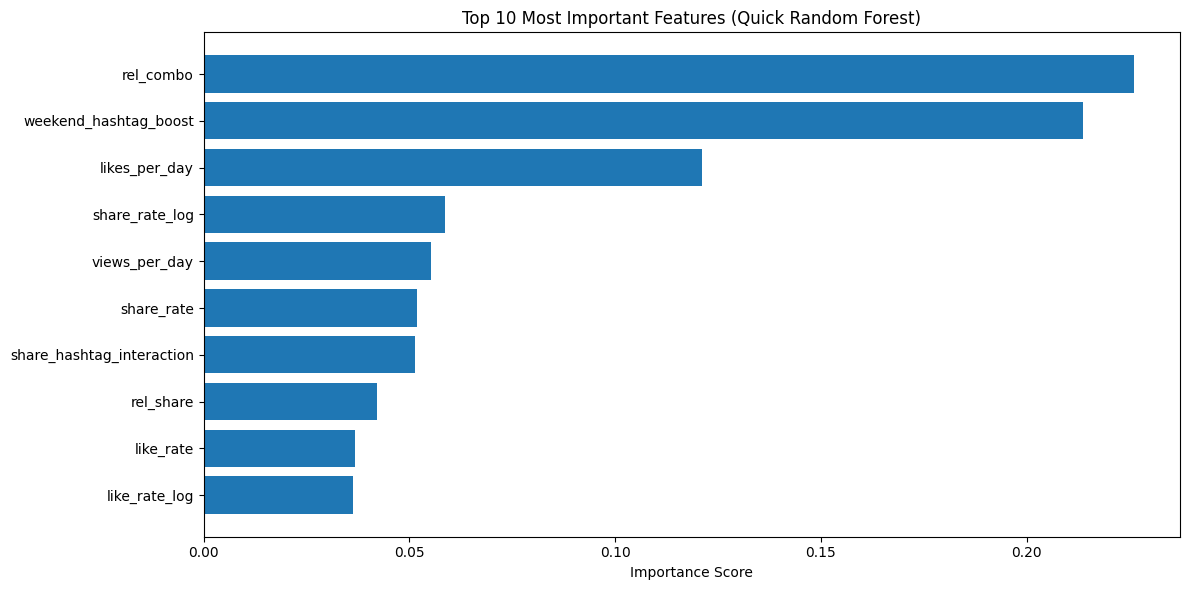

In [10]:
# METHOD 1: Quick Random Forest Feature Importance (No GridSearch)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Get numeric features only
X_numeric = df[numeric_features]

print("="*60)
print("METHOD 1: Quick Random Forest Feature Importance")
print("="*60)

# Train a quick random forest
quick_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
quick_rf.fit(X_numeric, y_encoded)

# Get feature importance
rf_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': quick_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features by Random Forest Importance:")
print(rf_importance.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(rf_importance['feature'][:10], rf_importance['importance'][:10])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (Quick Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


METHOD 2: Mutual Information Feature Importance

Top 10 Features by Mutual Information:
                  feature  mi_score
                rel_combo  0.350787
            likes_per_day  0.222184
    weekend_hashtag_boost  0.186356
share_hashtag_interaction  0.162874
               share_rate  0.162661
           share_rate_log  0.162498
                rel_share  0.152500
                like_rate  0.131444
 like_hashtag_interaction  0.131439
            like_rate_log  0.131437


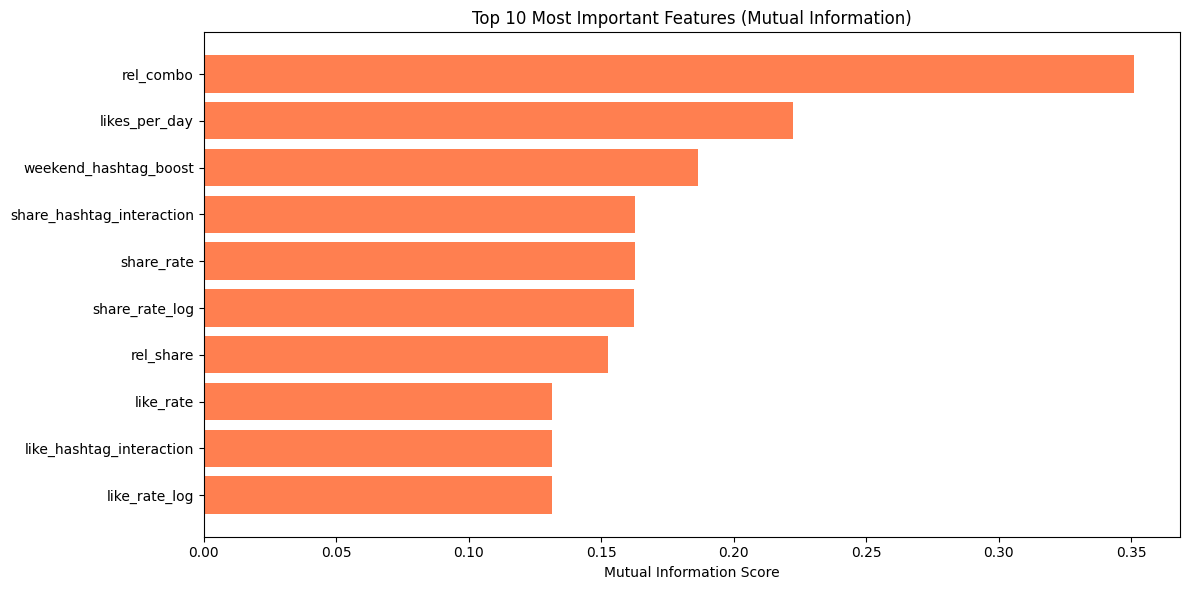

In [11]:
# METHOD 2: Mutual Information (Statistical Approach)
from sklearn.feature_selection import mutual_info_classif

print("\n" + "="*60)
print("METHOD 2: Mutual Information Feature Importance")
print("="*60)

# Calculate mutual information
mi_scores = mutual_info_classif(X_numeric, y_encoded, random_state=42)

mi_importance = pd.DataFrame({
    'feature': numeric_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(mi_importance.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(mi_importance['feature'][:10], mi_importance['mi_score'][:10], color='coral')
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Most Important Features (Mutual Information)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY: Combined Top 10 Features
print("\n" + "="*60)
print("FINAL SUMMARY: Top 10 Most Important Features")
print("="*60)

# Merge both methods
combined = rf_importance[['feature', 'importance']].rename(columns={'importance': 'RF_importance'})
combined = combined.merge(mi_importance[['feature', 'mi_score']].rename(columns={'mi_score': 'MI_score'}), on='feature')

# Calculate average rank
combined['RF_rank'] = combined['RF_importance'].rank(ascending=False)
combined['MI_rank'] = combined['MI_score'].rank(ascending=False)
combined['avg_rank'] = (combined['RF_rank'] + combined['MI_rank']) / 2
combined = combined.sort_values('avg_rank')

print("\nTop 10 Features (Consensus from both methods):")
print(combined[['feature', 'RF_importance', 'MI_score', 'avg_rank']].head(10).to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(10)
width = 0.35

top_10_features = combined.head(10)
ax.bar(x - width/2, top_10_features['RF_importance'], width, label='Random Forest', alpha=0.8)
ax.bar(x + width/2, top_10_features['MI_score']/top_10_features['MI_score'].max() * top_10_features['RF_importance'].max(), 
       width, label='Mutual Information (scaled)', alpha=0.8)

ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
ax.set_title('Top 10 Features: Comparison of Random Forest vs Mutual Information')
ax.set_xticks(x)
ax.set_xticklabels(top_10_features['feature'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RECOMMENDATION: Use these top 10 features for your model")
print("="*60)
print("\nTop 10 features to use:")
for i, row in combined.head(10).iterrows():
    print(f"{int(row['avg_rank']):2d}. {row['feature']}")